# Chronos-2 Single-Stage Anomaly Fine-Tuning — Loss Curves

Loads `trainer_state.json` from the single-stage checkpoint directory and plots the
**normal-future loss** and **anomaly-future loss** separately.

Both are the model's RAW prediction error (positive):
- **Normal loss** is minimized → should go **down**.
- **Anomaly loss** is maximized (gradient ascent) → should go **up** (until it hits the loss ceiling).

> **Note:** these separate curves require the per-type logging added to
> `finetune_anomaly_simple.py`. Runs started before that change only have the
> combined `loss`/`eval_loss` and will show empty normal/anomaly curves.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OUTPUT_DIR = "/home/rajib/chronos-forecasting/rajib_work_space/chronos2-single-stage_NS1000_V3"

In [2]:
def load_log_history(output_dir):
    """
    Find and load trainer_state.json from output_dir.
    Prefers finetuned-ckpt/, falls back to the highest checkpoint-NNNN/.
    """
    candidates = [os.path.join(output_dir ,"trainer_state.json")]
    if os.path.isdir(output_dir):
        for name in sorted(os.listdir(output_dir)):
            if name.startswith("checkpoint-"):
                candidates.append(os.path.join(output_dir, name, "trainer_state.json"))

    for path in reversed(candidates):
        if os.path.exists(path):
            with open(path) as f:
                history = json.load(f)["log_history"]
            print(f"Loaded {len(history)} entries from {path}")
            return history

    raise FileNotFoundError(f"No trainer_state.json found under {output_dir}")


def series(log_history, key):
    """Return (steps, values) for every entry that contains `key`."""
    steps, values = [], []
    for entry in log_history:
        if key in entry:
            steps.append(entry["step"])
            values.append(entry[key])
    return steps, values

In [3]:
history = load_log_history(OUTPUT_DIR)

# Train curves (per-type) + eval curves (per-type), all RAW positive losses
n_tr_s,  n_tr_l  = series(history, "normal_loss")
a_tr_s,  a_tr_l  = series(history, "anomaly_loss")
n_ev_s,  n_ev_l  = series(history, "eval_normal_loss")
a_ev_s,  a_ev_l  = series(history, "eval_anomaly_loss")

# Fallback: combined loss, if the run predates per-type logging
c_tr_s,  c_tr_l  = series(history, "loss")
c_ev_s,  c_ev_l  = series(history, "eval_loss")

print(f"normal_loss points: {len(n_tr_l)} | anomaly_loss points: {len(a_tr_l)}")
if not n_tr_l and not a_tr_l:
    print("No per-type losses found — this run predates per-type logging. "
          "Showing combined loss only.")

Loaded 34 entries from /home/rajib/chronos-forecasting/rajib_work_space/chronos2-single-stage_NS1000_V3/trainer_state.json
normal_loss points: 34 | anomaly_loss points: 34


/tmp/ipykernel_79633/70085573.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


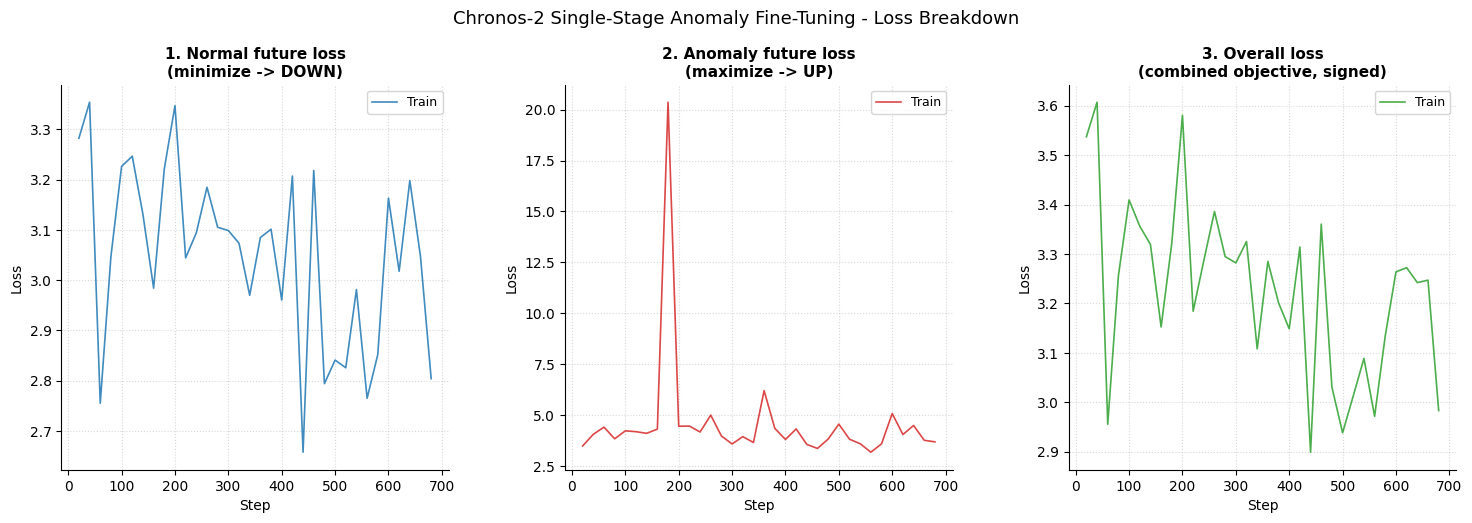

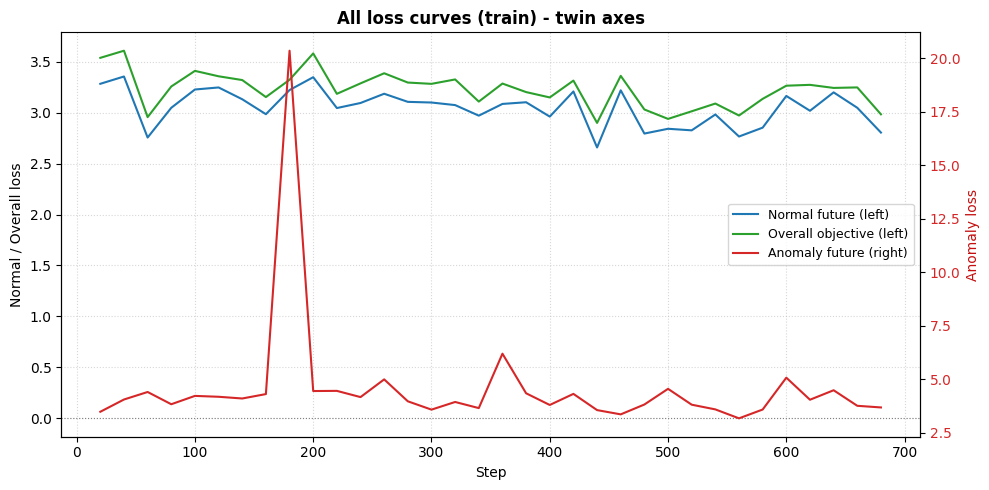

In [4]:
def plot_curve(ax, tr_s, tr_l, ev_s, ev_l, title, color):
    ax.plot(tr_s, tr_l, color=color, linewidth=1.2, label="Train", alpha=0.85)
    if ev_s:
        ax.plot(ev_s, ev_l, color=color, linewidth=1.8, linestyle="--",
                marker="o", markersize=3, label="Val", alpha=0.95)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ── Breakdown: three separate panels ────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, wspace=0.30)

ax1 = fig.add_subplot(gs[0])
plot_curve(ax1, n_tr_s, n_tr_l, n_ev_s, n_ev_l,
           "1. Normal future loss\n(minimize -> DOWN)", color="#1f77b4")

ax2 = fig.add_subplot(gs[1])
plot_curve(ax2, a_tr_s, a_tr_l, a_ev_s, a_ev_l,
           "2. Anomaly future loss\n(maximize -> UP)", color="#d62728")

ax3 = fig.add_subplot(gs[2])
plot_curve(ax3, c_tr_s, c_tr_l, c_ev_s, c_ev_l,
           "3. Overall loss\n(combined objective, signed)", color="#2ca02c")

fig.suptitle("Chronos-2 Single-Stage Anomaly Fine-Tuning - Loss Breakdown",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


fig2, axL = plt.subplots(figsize=(10, 5))
axR = axL.twinx()

lines = []
if n_tr_s: lines += axL.plot(n_tr_s, n_tr_l, color="#1f77b4", linewidth=1.5, label="Normal future (left)")
if c_tr_s: lines += axL.plot(c_tr_s, c_tr_l, color="#2ca02c", linewidth=1.5, label="Overall objective (left)")
if a_tr_s: lines += axR.plot(a_tr_s, a_tr_l, color="#d62728", linewidth=1.5, label="Anomaly future (right)")

axL.axhline(0, color="gray", linewidth=0.8, linestyle=":")
axL.set_xlabel("Step")
axL.set_ylabel("Normal / Overall loss")
axR.set_ylabel("Anomaly loss", color="#c40f0f")
axR.tick_params(axis="y", labelcolor="#d62728")
axL.set_title("All loss curves (train) - twin axes", fontsize=12, fontweight="bold")
axL.legend(lines, [ln.get_label() for ln in lines], fontsize=9, loc="best")
axL.grid(True, linestyle=":", alpha=0.5)
axL.spines["top"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curves_combined.png"), dpi=150, bbox_inches="tight")
plt.show()